# Black Hole Algorithm (BHA)

In [3]:
import math
import random
import statistics
import platform
import os
from typing import Callable
import time
 
import numpy as np
import matplotlib.pyplot as plt
from tabulate import tabulate
import pandas as pd
 
from sklearn.datasets import load_iris, load_wine, load_breast_cancer
from ucimlrepo import fetch_ucirepo
from sklearn.cluster import KMeans
from algorithms import kmeans_algorithm, pso_algorithm, bb_bc_algorithm

In [4]:
def load_dataset(name: str):
    if name == "iris":
        dataset = load_iris()
        X, y, k = dataset.data, dataset.target, 3

    elif name == "wine":
        dataset = load_wine()
        X, y, k = dataset.data, dataset.target, 3

    elif name == "cancer":
        dataset = fetch_ucirepo(id=15)
        df = dataset.data.features.apply(pd.to_numeric, errors="coerce")
        df = df.dropna()
        X = df.to_numpy(dtype=float)
        y = dataset.data.targets.loc[df.index].to_numpy().ravel()
        k = 2

    elif name == "glass":
        dataset = fetch_ucirepo(id=42)
        X = dataset.data.features.to_numpy(dtype=float)
        y = dataset.data.targets.to_numpy().ravel()
        k = len(np.unique(y))

    elif name == "cmc":
        dataset = fetch_ucirepo(id=30)
        X = dataset.data.features.to_numpy(dtype=float)
        y = dataset.data.targets.to_numpy().ravel()
        k = 3
    else:
        raise ValueError(f"unknown dataset: {name}")
 
    _, y = np.unique(y, return_inverse=True)
    return X.tolist(), y.tolist(), k


In [19]:
def get_cpu_name():
    if platform.system() == "Linux":
        try:
            with open("/proc/cpuinfo") as f:
                for line in f:
                    if line.startswith("model name"):
                        return line.split(":", 1)[1].strip()
        except Exception:
            pass
    return platform.processor() or platform.machine()

def get_system_specs():
    import psutil
    cpu = get_cpu_name()
    cores = os.cpu_count()
    ram_gb = psutil.virtual_memory().total / (1024 ** 3)
    return (f"{platform.system()} {platform.release()} | {cpu} | "
            f"{cores} cores | {ram_gb:.1f} GB RAM | Python {platform.python_version()}")

print(get_system_specs())

Linux 6.8.0-100-generic | 12th Gen Intel(R) Core(TM) i5-12400F | 12 cores | 15.5 GB RAM | Python 3.13.7


In [6]:
def compute_stats(values):
    return {
        "best":  min(values),
        "worst":  max(values),
        "average": statistics.mean(values),
        "std":  statistics.stdev(values) if len(values) > 1 else 0.0,
    }

In [7]:
def build_table(results, dataset_names):
    algorithms = list(results.keys())
    headers = ["Dataset", "Criteria"] + algorithms
    rows = []
    for name in dataset_names:
        for crit in ["best", "average", "worst", "std"]:
            row = [name if crit == "best" else "", crit]
            for algo in algorithms:
                stats = compute_stats(results[algo][name])
                row.append(stats[crit])
            rows.append(row)
    return headers, rows



In [8]:
def save_data(results, dataset_names, max_iterations, pop_size, num_runs, total_execution_time, filename='output.txt'):  
    headers, rows = build_table(results, dataset_names)

    with open(filename, 'w') as out_file:
        out_file.write('system specifications\n')
        out_file.write(f'{get_system_specs()}\n\n')
        out_file.write('experiment parameters\n')
        out_file.write(f'params: max_iterations={max_iterations}, population_size={pop_size}, number_of_runs={num_runs}\n\n')
                       
        out_file.write(tabulate(rows, headers=headers, tablefmt="github", floatfmt=".5f"))
        out_file.write('\n\n')
        out_file.write(f'total execution time: {total_execution_time}')


In [9]:
def make_clustering_evaluator(data: list[list[float]], K: int):
    d = len(data[0])
 
    def evaluate(star: list[float]) -> float:
        total = 0.0
        for point in data:
            best = float("inf")
            for k in range(K):
                base = k * d
                dist2 = 0.0
                for j in range(d):
                    diff = point[j] - star[base + j]
                    dist2 += diff * diff
                if dist2 < best:
                    best = dist2
            total += math.sqrt(best)
        return total
 
    return evaluate, K * d


In [10]:
def make_bounds(data: list[list[float]], K: int):
    d = len(data[0])
    feat_min = [min(row[j] for row in data) for j in range(d)]
    feat_max = [max(row[j] for row in data) for j in range(d)]
    return feat_min * K, feat_max * K


In [11]:
def uniform(lower_bound, upper_bound, j):
    return random.uniform(lower_bound[j] if isinstance(lower_bound, list) else lower_bound,
                          upper_bound[j] if isinstance(upper_bound, list) else upper_bound)


In [12]:
def clip(x, lower_bound, upper_bound, j):
    low = lower_bound[j] if isinstance(lower_bound, list) else lower_bound
    high = upper_bound[j] if isinstance(upper_bound, list) else upper_bound
    return max(low, min(high, x))


In [13]:
def initialize_star(data, k) -> list[float]:
    star = []
    for _ in range(k):
        star.extend(data[random.randrange(len(data))])
    return star

In [14]:
def black_hole_algorithm(dimension: int, max_iterations: int, star_num: int, lower_bound: float, upper_bound: float, evaluate: Callable, data: list[list[float]], k: int) -> tuple[list[float], float, list[float]]:
    stars = [initialize_star(data, k) for _ in range(star_num)]
    fitness = [evaluate(star) for star in stars]

    black_hole_index = min(range(star_num), key=lambda i: fitness[i])
    black_hole = stars[black_hole_index][:]
    best_value = fitness[black_hole_index]
    
    convergence = []

    for _ in range(1, max_iterations + 1):
        for i in range(star_num):
            if i != black_hole_index:
                star = stars[i]
                rand = random.random()

                new_star = [clip(star[j] + rand * (black_hole[j] - star[j]), lower_bound, upper_bound, j) for j in range(dimension)]

                stars[i] = new_star
                fitness[i] = evaluate(new_star)
        
        current_best_index = min(range(star_num), key=lambda i: fitness[i])
        if fitness[current_best_index] < best_value:
            black_hole_index = current_best_index
            black_hole = stars[current_best_index][:]
            best_value = fitness[current_best_index]

        total_fitness = sum(fitness)
        event_horizon_radius = best_value / total_fitness if total_fitness != 0 else 0

        for i in range(star_num):
            if i != black_hole_index:
                distance  = math.sqrt(sum((stars[i][j] - black_hole[j]) ** 2 for j in range(dimension)))

                if distance < event_horizon_radius:
                    stars[i] = initialize_star(data, k)
                    fitness[i] = evaluate(stars[i])
        
        convergence.append(best_value)
    
    return black_hole, best_value, convergence

In [15]:
def run_benchmarks(dataset_names, algorithms, max_iterations=500, pop_size=30, num_runs=30):
    results = {algo_name: {dataset_name: [] for dataset_name in dataset_names} for algo_name in algorithms}
    convergences = {algo_name: {func_name: [] for func_name in dataset_names} for algo_name in algorithms}
    
    for dataset_name in dataset_names:
        data, labels, k = load_dataset(dataset_name)
        evaluate, dimension = make_clustering_evaluator(data, k)
        lower_bound, upper_bound = make_bounds(data, k)

        for algo_name, algo in algorithms.items():
                for _ in range(num_runs):
                    _, best_value, convergence = algo(dimension, max_iterations, pop_size, lower_bound, upper_bound, evaluate, data, k )

                    results[algo_name][dataset_name].append(best_value)
                    convergences[algo_name][dataset_name].append(convergence)
    
    return results, convergences

In [16]:
def plot_convergence(dataset_names, convergences, log_scale=False):
    n = len(dataset_names)
    cols = 3
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = axes.flatten()

    for idx, dataset_name in enumerate(dataset_names):
        ax = axes[idx]
        for algo_name, fn_dict in convergences.items():
            runs = fn_dict[dataset_name]
            mean_curve = [sum(c) / len(c) for c in zip(*runs)]
            ax.plot(mean_curve, label=algo_name)
        ax.set_title(dataset_name)
        ax.set_xlabel("iteration")
        ax.set_ylabel("sum of intra-cluster distances")
        if log_scale:
            ax.set_yscale("log")
        ax.legend()
        ax.grid(True, alpha=0.3)

    for j in range(n, len(axes)):
        axes[j].axis("off")

    fig.suptitle("convergence on clustering datasets")
    fig.tight_layout()
    fig.savefig("convergence.png", dpi=150)

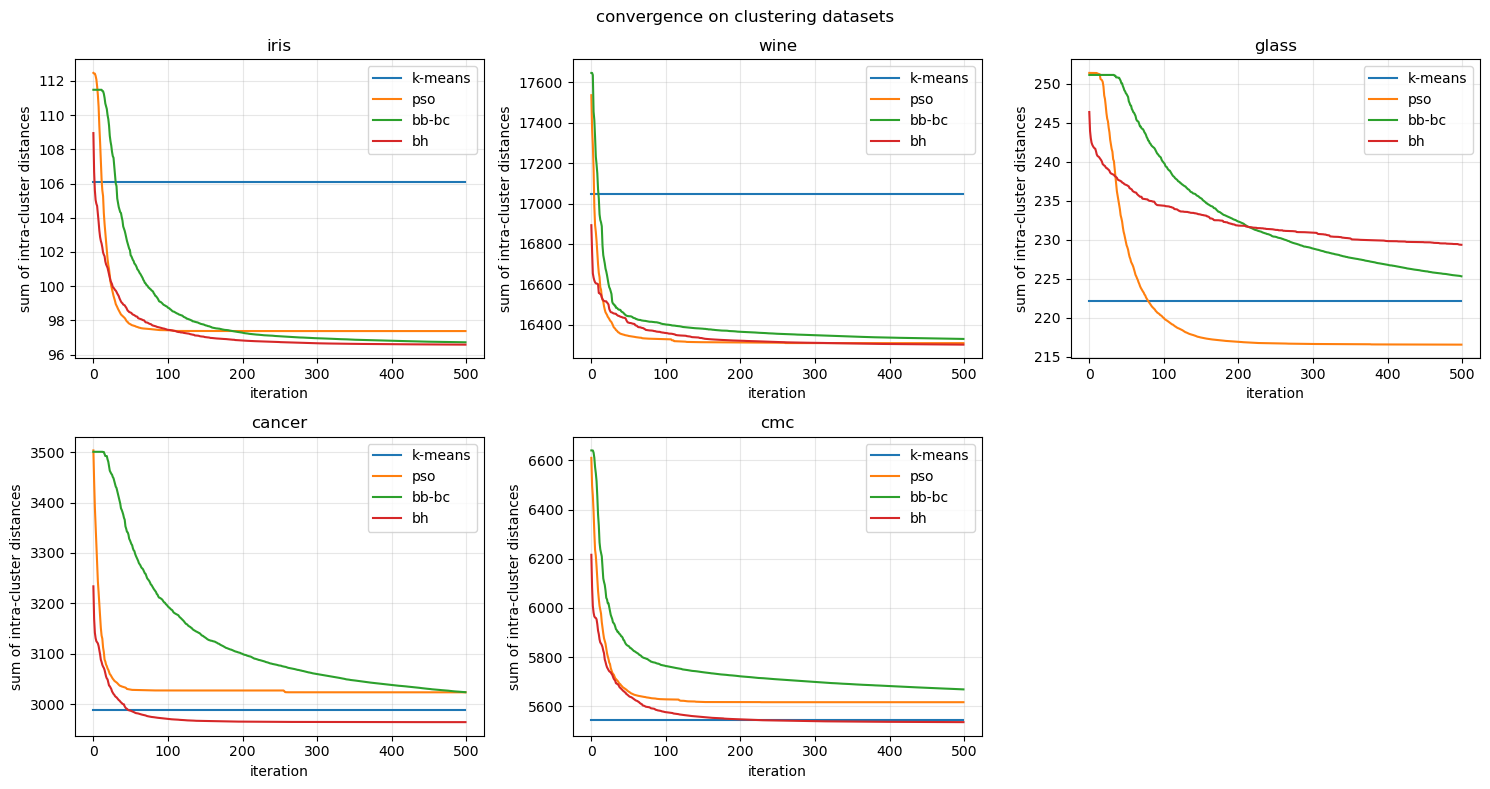

In [17]:
def main():
    dataset_names = ["iris", "wine", "glass", "cancer", "cmc"]
    algorithms = {
        "k-means": kmeans_algorithm,
        "pso": pso_algorithm,
        "bb-bc": bb_bc_algorithm,
        "bh": black_hole_algorithm
    }
    max_iterations, pop_size, num_runs = 500, 30, 30
    
    start_time = time.perf_counter()

    results, convergences = run_benchmarks(
        dataset_names, algorithms,
        max_iterations=max_iterations, pop_size=pop_size, num_runs=num_runs,
    )
    
    end_time = time.perf_counter()
    total_execution_time = end_time - start_time

    hours = int(total_execution_time // 3600)
    minutes = int((total_execution_time % 3600) // 60)
    seconds = total_execution_time % 60
    
    total_execution_time_string = f'{hours}h {minutes}m {seconds:.4f}s'

    save_data(results, dataset_names, max_iterations, pop_size, num_runs, total_execution_time_string)

    plot_convergence(dataset_names, convergences)

if __name__ == "__main__":
    main()